In [100]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
from scipy.signal import argrelmin
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime, hl1, hl1prime, e_r_recursive_cpa

### This notebook concerns the paper [Surface plasmons and strong light-matter coupling in metallic nanoshells](https://scholar.archive.org/work/ojws3hap2jb7nax3evbj4jet2m/access/wayback/http://fisica.unipv.it/nanophotonics/Pubs/AlpeggianiPRB2012.pdf). In particular, we compare their Figure 1 with what one would obtain if retardation is included. 

In [207]:
def quasistatic_dispersion(l, omega_p, a, A):
    void_mode_sqrd = (omega_p**2/2)*(1+1/(2*l+1)*sqrt(1+4*l*(l+1)*(a/A)**(2*l+1)))
    sphere_mode_sqrd = (omega_p**2/2)*(1-1/(2*l+1)*sqrt(1+4*l*(l+1)*(a/A)**(2*l+1)))
    return sphere_mode_sqrd, void_mode_sqrd
def drude(omega_over_omega_p):
    return 1-1/(omega_over_omega_p**2)
# From de Abajo paper
def paper_method(l, epsilon, R, H, omega):
    rho_b = R*omega
    rho_a = (R+H)*omega
    eta_b = sqrt(epsilon)*rho_b
    eta_a = sqrt(epsilon)*rho_a

    rho_b_jlprime = spherical_jn(l, rho_b) + rho_b*spherical_jn(l, rho_b, derivative=True)
    eta_b_jlprime = spherical_jn(l, eta_b) + eta_b*spherical_jn(l, eta_b, derivative=True)
    eta_a_jlprime = spherical_jn(l, eta_a) + eta_a*spherical_jn(l, eta_a, derivative=True)

    rho_a_hlprime = hl1(l, rho_a) + rho_a*hl1prime(l, rho_a)
    eta_b_hlprime = hl1(l, eta_b) + eta_b*hl1prime(l, eta_b)
    eta_a_hlprime = hl1(l, eta_a) + eta_a*hl1prime(l, eta_a)

    D_l = eta_b_jlprime*hl1(l, eta_a)-eta_b_hlprime*spherical_jn(l, eta_a)
    C_l = spherical_jn(l, eta_b)*hl1(l, eta_a) - spherical_jn(l, eta_a)*hl1(l, eta_b)
    B_l = eta_b_jlprime * eta_a_hlprime - eta_a_jlprime * eta_b_hlprime
    A_l = spherical_jn(l, eta_b)*eta_a_hlprime - hl1(l, eta_b)*eta_a_jlprime

    beta_l = epsilon * (epsilon * rho_b_jlprime * C_l - spherical_jn(l, rho_b) * D_l)
    alpha_l = epsilon * rho_b_jlprime * A_l - spherical_jn(l, rho_b) * B_l

    LHS = hl1(l, rho_a) * alpha_l
    RHS = beta_l * rho_a_hlprime
    return LHS - RHS

### The function, paper_method, defined above, is from the paper: [Radiative decay of plasmons in a metallic nanoshell](https://link.aps.org/pdf/10.1103/PhysRevB.69.155402?casa_token=ysrofqx3MhMAAAAA:PO2xtgoR8T6w5glk_0FlmUHMIk5X6qtD1tdgkH6TqaDN3p0EXLMs_s-OFhfZkDREXNWQ3-83KUphDw).

In [208]:
A = 1
N = 1000
omega_p = 1
a_s_non_retarded = linspace(0, 1, N)
void_modes = []
sphere_modes = []
ls = [1, 2, 3, 4]
for l in ls:
    void_mode_sqrd, sphere_mode_sqrd = quasistatic_dispersion(l, omega_p, a_s_non_retarded, A)
    void_mode = sqrt(void_mode_sqrd)
    sphere_mode = sqrt(sphere_mode_sqrd)
    void_modes.append(void_mode)
    sphere_modes.append(sphere_mode)

In [204]:
N = 1000
a_s_retarded = linspace(0.01, 0.99, N)
omega_over_omega_ps_below_sp = linspace(0.01, 1/sqrt(2), N).reshape((1, N)).repeat(N, axis=0)
omega_over_omega_ps_above_sp = linspace(1/sqrt(2), 0.999, N).reshape((1, N)).repeat(N, axis=0)

scattering_amplitudes_above_sp_v = []
scattering_amplitudes_below_sp_v = []

for l in ls:
    print("Angular momentum, l, is: ", l)
    epsilon = drude(omega_over_omega_ps_below_sp) + 0j;
    a_s = a_s_retarded.reshape((N, 1)).repeat(N, axis=1)
    scattering_amplitudes_below_sp = np.abs(paper_method(l, epsilon, 0.1*a_s/omega_over_omega_ps_below_sp, 0.1*(1-a_s)/omega_over_omega_ps_below_sp, omega_over_omega_ps_below_sp))
    
    epsilon = drude(omega_over_omega_ps_above_sp) + 0j;
    scattering_amplitudes_above_sp = np.abs(paper_method(l, epsilon, 0.1*a_s/omega_over_omega_ps_above_sp, 0.1*(1-a_s)/omega_over_omega_ps_above_sp, omega_over_omega_ps_above_sp))

    scattering_amplitudes_below_sp_v.append(scattering_amplitudes_below_sp) 
    scattering_amplitudes_above_sp_v.append(scattering_amplitudes_above_sp) 

Angular momentum, l, is:  1
Angular momentum, l, is:  2
Angular momentum, l, is:  3
Angular momentum, l, is:  4


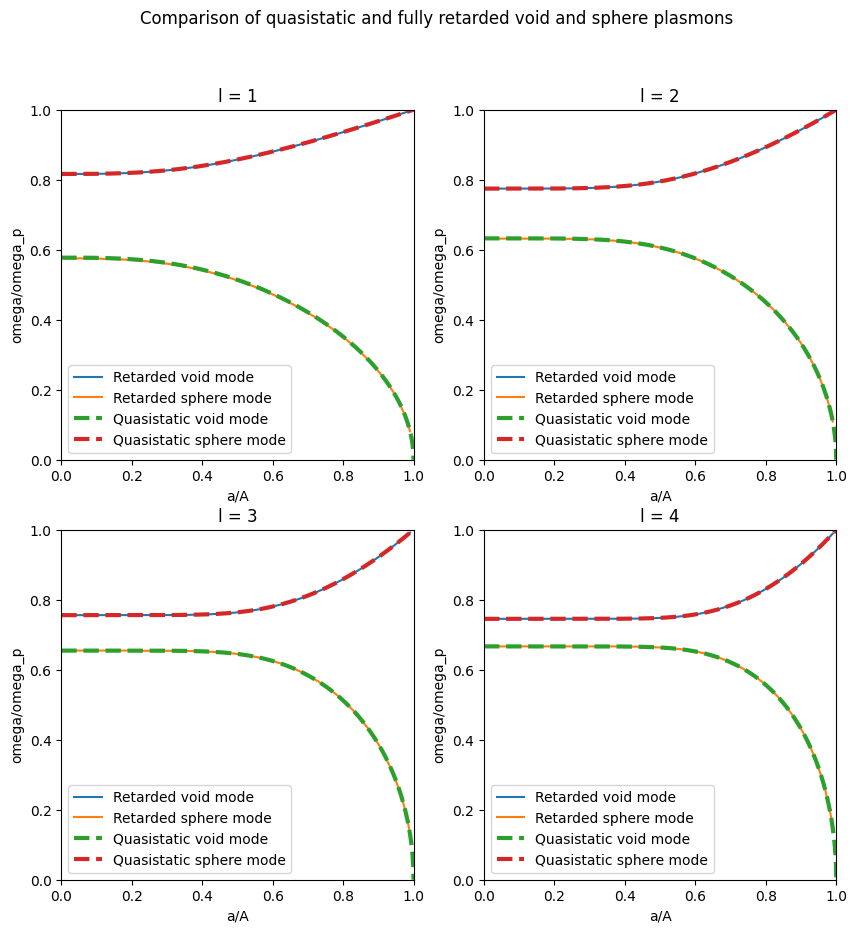

In [217]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 10))
omega_over_omega_ps_below_sp = linspace(0.01, 1/sqrt(2), N)
omega_over_omega_ps_above_sp = linspace(1/sqrt(2), 0.999, N)

for (ax_idx, ax) in enumerate([ax1, ax2, ax3, ax4]):
    scattering_amplitudes_below_sp = scattering_amplitudes_below_sp_v[ax_idx]
    scattering_amplitudes_above_sp = scattering_amplitudes_above_sp_v[ax_idx]
    retard_plasmon_above_sp = omega_over_omega_ps_above_sp[argmin(scattering_amplitudes_above_sp, axis=1)]
    retard_plasmon_below_sp = omega_over_omega_ps_below_sp[argmin(scattering_amplitudes_below_sp, axis=1)]

    ax.plot(a_s_retarded, retard_plasmon_above_sp, label="Retarded void mode")
    ax.plot(a_s_retarded, retard_plasmon_below_sp, label="Retarded sphere mode");
    ax.plot(a_s_non_retarded, void_modes[ax_idx], linestyle="dashed", linewidth=3, label="Quasistatic void mode")
    ax.plot(a_s_non_retarded, sphere_modes[ax_idx], linestyle="dashed", linewidth=3, label="Quasistatic sphere mode");
    ax.set_title(f"l = {ax_idx+1}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1);
    ax.set_xlabel("a/A")
    ax.set_ylabel("omega/omega_p")
    ax.legend();
fig.suptitle("Comparison of quasistatic and fully retarded void and sphere plasmons");

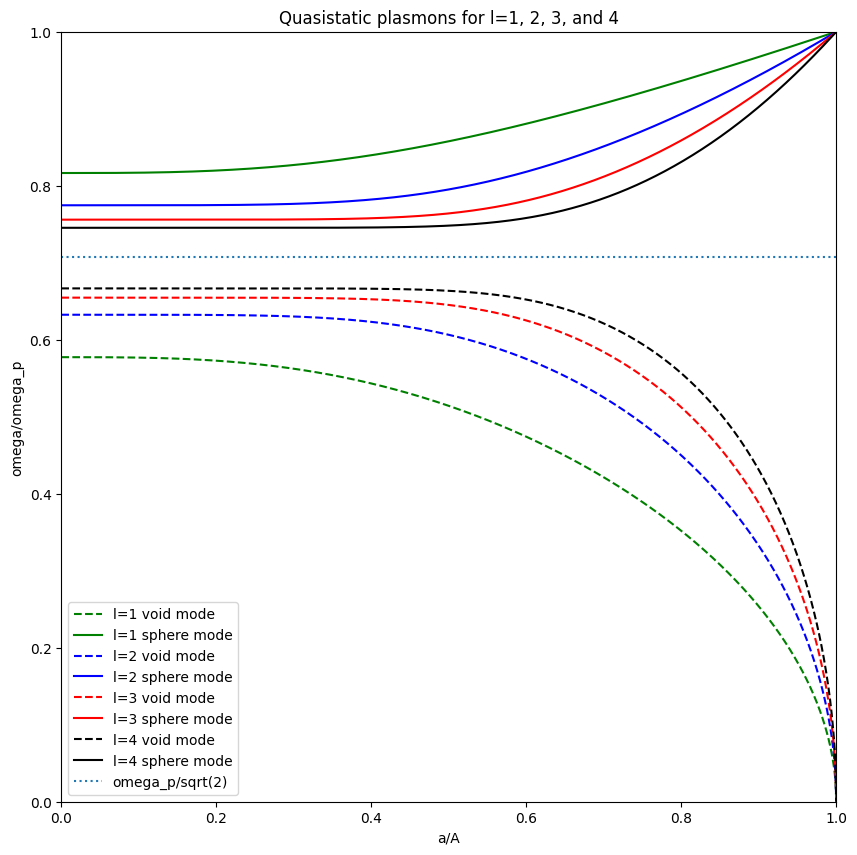

In [215]:
fig, ax = plt.subplots(figsize=(10, 10));
colors = ["green", "blue", "red", "black"]
for (l, color, void_mode, sphere_mode) in zip(ls, colors, void_modes, sphere_modes):
    ax.plot(a_s_non_retarded, void_mode, label=f"l={l} void mode", color=color, linestyle="dashed")
    ax.plot(a_s_non_retarded, sphere_mode, color=color, label=f"l={l} sphere mode")
ax.hlines(omega_p/sqrt(2), 0, 1, linestyle="dotted", label="omega_p/sqrt(2)")
ax.set_xlim(0, 1);
ax.set_ylim(0, 1);
ax.legend();
ax.set_title("Quasistatic plasmons for l=1, 2, 3, and 4")
ax.set_xlabel("a/A")
ax.set_ylabel("omega/omega_p");